# Question 3: San Francisco Crime Classification

This notebook builds **two tree models** and **one Support Vector Machine** for the Kaggle **San Francisco Crime Classification** competition. The task is multiclass classification: predict the probability of each crime category for every incident in the test set. Kaggle evaluates submissions using multiclass logarithmic loss, so the notebook outputs probability columns for all crime categories rather than only one predicted class.

Models submitted/evaluated:
1. Decision Tree Classifier
2. Random Forest Classifier
3. Calibrated Linear Support Vector Machine

> Run this notebook in Kaggle after adding the competition data. It writes three Kaggle-ready submission files and includes a final section where a Kaggle submission screenshot can be inserted as evidence.

In [27]:
# Core packages
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import log_loss, accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.base import clone

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load Kaggle data
The Kaggle competition files may appear as zipped CSV files, for example `/kaggle/input/competitions/sf-crime/train.csv.zip` and `test.csv.zip`. The code below searches for both `.csv` and `.csv.zip` versions and reads them directly with pandas.

In [28]:
def find_file(filename):
    """Find a Kaggle competition file, allowing either CSV or zipped CSV inputs."""
    base_names = [filename]
    if filename.endswith('.csv'):
        base_names.append(filename + '.zip')

    candidate_dirs = [
        '/kaggle/input/competitions/sf-crime',
        '/kaggle/input/sf-crime',
        '/kaggle/input/san-francisco-crime-classification',
        '.',
        '../input/sf-crime',
    ]

    for directory in candidate_dirs:
        for name in base_names:
            p = os.path.join(directory, name)
            if os.path.exists(p):
                return p

    # Broader search fallback across Kaggle input folders
    search_root = '/kaggle/input' if os.path.exists('/kaggle/input') else '.'
    for root, dirs, files in os.walk(search_root):
        for name in base_names:
            if name in files:
                return os.path.join(root, name)

    raise FileNotFoundError(
        f'Could not find {filename} or {filename}.zip. Add the Kaggle competition data to the notebook.'
    )

train_path = find_file('train.csv')
test_path = find_file('test.csv')
sample_path = find_file('sampleSubmission.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print('Train path:', train_path)
print('Test path:', test_path)
print('Sample submission path:', sample_path)
print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Sample submission shape:', sample_submission.shape)
train.head()


Train path: /kaggle/input/competitions/sf-crime/train.csv.zip
Test path: /kaggle/input/competitions/sf-crime/test.csv.zip
Sample submission path: /kaggle/input/competitions/sf-crime/sampleSubmission.csv.zip
Train shape: (878049, 9)
Test shape: (884262, 7)
Sample submission shape: (884262, 40)


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541


## 2. Data overview
The target variable is `Category`. The variables `Descript` and `Resolution` are not available in the test set, so they are excluded from modeling to avoid leakage.

In [29]:
print(train.info())
print('\nTarget classes:', train['Category'].nunique())
print(train['Category'].value_counts().head(10))
print('\nMissing values in train:')
print(train.isna().sum())
print('\nMissing values in test:')
print(test.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878049 entries, 0 to 878048
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Dates       878049 non-null  object 
 1   Category    878049 non-null  object 
 2   Descript    878049 non-null  object 
 3   DayOfWeek   878049 non-null  object 
 4   PdDistrict  878049 non-null  object 
 5   Resolution  878049 non-null  object 
 6   Address     878049 non-null  object 
 7   X           878049 non-null  float64
 8   Y           878049 non-null  float64
dtypes: float64(2), object(7)
memory usage: 60.3+ MB
None

Target classes: 39
Category
LARCENY/THEFT     174900
OTHER OFFENSES    126182
NON-CRIMINAL       92304
ASSAULT            76876
DRUG/NARCOTIC      53971
VEHICLE THEFT      53781
VANDALISM          44725
WARRANTS           42214
BURGLARY           36755
SUSPICIOUS OCC     31414
Name: count, dtype: int64

Missing values in train:
Dates         0
Category      0
Descrip

## 3. Feature engineering
Features are based only on fields available in both train and test sets. The notebook extracts time features, location features, and simple address indicators. Invalid coordinate pairs at `(X=-120.5, Y=90.0)` are replaced with missing values and imputed later.

In [30]:
def add_features(df):
    df = df.copy()
    df['Dates'] = pd.to_datetime(df['Dates'])
    df['Year'] = df['Dates'].dt.year
    df['Month'] = df['Dates'].dt.month
    df['Day'] = df['Dates'].dt.day
    df['Hour'] = df['Dates'].dt.hour
    df['Minute'] = df['Dates'].dt.minute
    df['WeekOfYear'] = df['Dates'].dt.isocalendar().week.astype(int)
    df['IsWeekend'] = df['DayOfWeek'].isin(['Saturday','Sunday']).astype(int)
    df['IsNight'] = df['Hour'].between(0, 5).astype(int)
    df['IsBusinessHour'] = df['Hour'].between(8, 17).astype(int)
    df['HourSin'] = np.sin(2*np.pi*df['Hour']/24)
    df['HourCos'] = np.cos(2*np.pi*df['Hour']/24)
    df['MonthSin'] = np.sin(2*np.pi*df['Month']/12)
    df['MonthCos'] = np.cos(2*np.pi*df['Month']/12)
    df['IsIntersection'] = df['Address'].str.contains(' / ', regex=False).astype(int)
    df['IsBlock'] = df['Address'].str.contains('Block', case=False, na=False).astype(int)
    df['AddressClean'] = df['Address'].str.replace(r'\d+ Block of ', '', regex=True).str.strip()
    bad_xy = (df['X'].round(1) == -120.5) & (df['Y'].round(1) == 90.0)
    df.loc[bad_xy, ['X','Y']] = np.nan
    df['XY_missing'] = bad_xy.astype(int)
    return df

train_fe = add_features(train)
test_fe = add_features(test)

features = [
    'DayOfWeek', 'PdDistrict', 'AddressClean',
    'X', 'Y', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'WeekOfYear',
    'IsWeekend', 'IsNight', 'IsBusinessHour', 'HourSin', 'HourCos', 'MonthSin', 'MonthCos',
    'IsIntersection', 'IsBlock', 'XY_missing'
]

target = 'Category'
X = train_fe[features]
y = train_fe[target]
X_test = test_fe[features]

print(X.shape, y.shape, X_test.shape)


(878049, 21) (878049,) (884262, 21)


## 4. Validation split and preprocessing
A stratified validation split is used because the response has many imbalanced classes. Categorical variables are one-hot encoded and numeric variables are imputed and standardized. Large high-cardinality address encoding can be memory intensive, so rare addresses are grouped into `OtherAddress`.

In [31]:
# Reduce address cardinality for speed and generalization
address_counts = X['AddressClean'].value_counts()
top_addresses = set(address_counts[address_counts >= 50].index)

for df in [X, X_test]:
    df.loc[:, 'AddressClean'] = df['AddressClean'].where(df['AddressClean'].isin(top_addresses), 'OtherAddress')

categorical_features = ['DayOfWeek', 'PdDistrict', 'AddressClean']
numeric_features = [c for c in features if c not in categorical_features]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Optional sampling to keep late-submission notebooks fast. Increase for better Kaggle scores.
MAX_TRAIN_ROWS = 250000
if len(X_train) > MAX_TRAIN_ROWS:
    sample_idx, _ = next(StratifiedShuffleSplit(n_splits=1, train_size=MAX_TRAIN_ROWS, random_state=RANDOM_STATE).split(X_train, y_train))
    X_train_model = X_train.iloc[sample_idx].copy()
    y_train_model = y_train.iloc[sample_idx].copy()
else:
    X_train_model = X_train.copy()
    y_train_model = y_train.copy()

print('Training rows used for model fitting:', X_train_model.shape[0])

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', ohe)]), categorical_features)
    ],
    remainder='drop'
)

classes = list(sample_submission.columns[1:])
print('Submission class count:', len(classes))


Training rows used for model fitting: 250000
Submission class count: 39


## 5. Helper functions for multiclass log-loss and Kaggle submissions

In [32]:
def align_probabilities(model, X_input, classes_from_submission):
    proba = model.predict_proba(X_input)
    model_classes = list(model.classes_)
    aligned = np.zeros((X_input.shape[0], len(classes_from_submission)))
    for i, cls in enumerate(classes_from_submission):
        if cls in model_classes:
            aligned[:, i] = proba[:, model_classes.index(cls)]
        else:
            aligned[:, i] = 1e-15
    # Avoid exact zero/one for log loss and normalize rows
    aligned = np.clip(aligned, 1e-15, 1 - 1e-15)
    aligned = aligned / aligned.sum(axis=1, keepdims=True)
    return aligned

def evaluate_model(name, model):
    model.fit(X_train_model, y_train_model)
    valid_proba = align_probabilities(model, X_valid, classes)
    valid_pred = np.array(classes)[np.argmax(valid_proba, axis=1)]
    ll = log_loss(y_valid, valid_proba, labels=classes)
    acc = accuracy_score(y_valid, valid_pred)
    print(f'{name} validation log loss: {ll:.4f}')
    print(f'{name} validation accuracy: {acc:.4f}')
    return {'model': model, 'log_loss': ll, 'accuracy': acc, 'valid_proba': valid_proba, 'valid_pred': valid_pred}

def make_submission(model, filename):
    test_proba = align_probabilities(model, X_test, classes)
    sub = pd.DataFrame(test_proba, columns=classes)
    sub.insert(0, 'Id', test['Id'])
    sub.to_csv(filename, index=False)
    print(f'Wrote {filename}:', sub.shape)
    return sub


## 6. Model 1: Decision Tree Classifier
The decision tree is interpretable because predictions are based on hierarchical splits. It is expected to capture nonlinear relationships between time, district, address type, and location, but it can overfit if not pruned or depth-limited.

In [33]:
decision_tree = Pipeline([
    ('prep', clone(preprocess)),
    ('model', DecisionTreeClassifier(
        max_depth=18,
        min_samples_leaf=150,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

dt_results = evaluate_model('Decision Tree', decision_tree)


Decision Tree validation log loss: 3.6810
Decision Tree validation accuracy: 0.0558


## 7. Model 2: Random Forest Classifier
The random forest is the second tree model. It averages many trees, which usually lowers variance and improves generalization compared with a single tree, although interpretation becomes less direct.

In [34]:
random_forest = Pipeline([
    ('prep', clone(preprocess)),
    ('model', RandomForestClassifier(
        n_estimators=150,
        max_depth=22,
        min_samples_leaf=50,
        max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_results = evaluate_model('Random Forest', random_forest)


Random Forest validation log loss: 3.4609
Random Forest validation accuracy: 0.0645


## 8. Model 3: Calibrated Linear Support Vector Machine
A standard kernel SVC is usually too slow for this large sparse multiclass dataset. Therefore, this notebook uses a LinearSVC with probability calibration. The SVM training sample is now selected with a class-based stratified strategy so that rare crime categories remain represented and calibration does not fail from having too few examples per class.

In [35]:
# SVM calibration is computationally heavier, so use a class-based stratified sample.
# This avoids the error where 3-fold calibration receives fewer than 3 examples for a rare class.
MAX_SVM_ROWS = 120000
n_classes = y_train.nunique()
max_per_class = max(1, MAX_SVM_ROWS // n_classes)

svm_sample_parts = []
for cls, idx in y_train.groupby(y_train).groups.items():
    idx = list(idx)
    n_take = min(len(idx), max_per_class)
    sampled_idx = pd.Series(idx).sample(n=n_take, random_state=RANDOM_STATE).values
    svm_sample_parts.append(X_train.loc[sampled_idx].assign(Category=cls))

svm_train_sample = pd.concat(svm_sample_parts, axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
y_train_svm = svm_train_sample['Category']
X_train_svm = svm_train_sample.drop(columns=['Category'])

svm_class_counts = y_train_svm.value_counts()
min_class_count = int(svm_class_counts.min())
cv_folds = min(3, min_class_count)

print('SVM sample shape:', X_train_svm.shape)
print('Number of classes in SVM sample:', y_train_svm.nunique())
print('Minimum class count in SVM sample:', min_class_count)
print('Calibration folds used:', cv_folds)

if cv_folds < 2:
    raise ValueError(
        'At least one class has fewer than 2 examples in the SVM sample. '
        'Increase MAX_SVM_ROWS or use the full training data for SVM calibration.'
    )

svm = Pipeline([
    ('prep', clone(preprocess)),
    ('model', CalibratedClassifierCV(
        estimator=LinearSVC(C=0.50, class_weight='balanced', random_state=RANDOM_STATE, max_iter=4000),
        method='sigmoid',
        cv=cv_folds
    ))
])

svm.fit(X_train_svm, y_train_svm)
svm_valid_proba = align_probabilities(svm, X_valid, classes)
svm_valid_pred = np.array(classes)[np.argmax(svm_valid_proba, axis=1)]
svm_results = {
    'model': svm,
    'log_loss': log_loss(y_valid, svm_valid_proba, labels=classes),
    'accuracy': accuracy_score(y_valid, svm_valid_pred),
    'valid_proba': svm_valid_proba,
    'valid_pred': svm_valid_pred
}
print(f"Calibrated Linear SVM validation log loss: {svm_results['log_loss']:.4f}")
print(f"Calibrated Linear SVM validation accuracy: {svm_results['accuracy']:.4f}")


SVM sample shape: (81890, 21)
Number of classes in SVM sample: 39
Minimum class count in SVM sample: 5
Calibration folds used: 3
Calibrated Linear SVM validation log loss: 3.0944
Calibrated Linear SVM validation accuracy: 0.1114


## 9. Validation comparison

In [36]:
results_table = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Calibrated Linear SVM'],
    'Validation Log Loss': [dt_results['log_loss'], rf_results['log_loss'], svm_results['log_loss']],
    'Validation Accuracy': [dt_results['accuracy'], rf_results['accuracy'], svm_results['accuracy']]
}).sort_values('Validation Log Loss')
results_table


,Model,Validation Log Loss,Validation Accuracy
2,Calibrated Linear SVM,3.094424,0.111446
1,Random Forest,3.460907,0.064455
0,Decision Tree,3.680996,0.055800


Best validation model by log loss: Calibrated Linear SVM


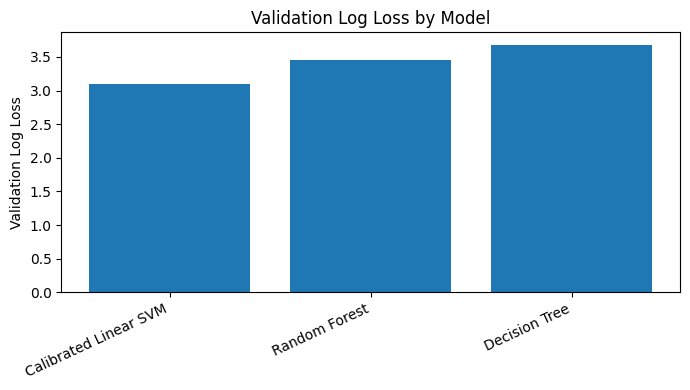

In [37]:
best_name = results_table.iloc[0]['Model']
print('Best validation model by log loss:', best_name)

plt.figure(figsize=(7,4))
plt.bar(results_table['Model'], results_table['Validation Log Loss'])
plt.ylabel('Validation Log Loss')
plt.title('Validation Log Loss by Model')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 10. Interpretation and diagnostics
For this multiclass problem, the strongest predictors are expected to be temporal patterns, police district, address/intersection indicators, and coordinates. Assumption checks focus on classification diagnostics rather than regression assumptions: leakage, class imbalance, probability calibration, sparse categorical levels, and geographic outliers.

In [38]:
# Classification report for the best model, limited output can be long.
model_lookup = {
    'Decision Tree': dt_results,
    'Random Forest': rf_results,
    'Calibrated Linear SVM': svm_results
}
best_results = model_lookup[best_name]
print(classification_report(y_valid, best_results['valid_pred'], zero_division=0))


                             precision    recall  f1-score   support

                      ARSON       0.04      0.04      0.04       303
                    ASSAULT       0.11      0.00      0.00     15375
                 BAD CHECKS       0.00      0.00      0.00        81
                    BRIBERY       0.00      0.00      0.00        58
                   BURGLARY       0.11      0.20      0.14      7351
         DISORDERLY CONDUCT       0.03      0.19      0.05       864
DRIVING UNDER THE INFLUENCE       0.02      0.32      0.04       454
              DRUG/NARCOTIC       0.25      0.39      0.31     10794
                DRUNKENNESS       0.02      0.22      0.04       856
               EMBEZZLEMENT       0.01      0.03      0.01       233
                  EXTORTION       0.00      0.00      0.00        51
            FAMILY OFFENSES       0.00      0.00      0.00        98
     FORGERY/COUNTERFEITING       0.04      0.44      0.07      2122
                      FRAUD      

In [39]:
# Top predicted classes in validation
pred_counts = pd.Series(best_results['valid_pred']).value_counts().head(15)
actual_counts = y_valid.value_counts().head(15)
comparison_counts = pd.DataFrame({'Actual top counts': actual_counts, 'Predicted top counts': pred_counts}).fillna(0).astype(int)
comparison_counts


,Actual top counts,Predicted top counts
ASSAULT,15375,0
BURGLARY,7351,14171
DISORDERLY CONDUCT,0,5853
DRIVING UNDER THE INFLUENCE,0,7826
DRUG/NARCOTIC,10794,16457
DRUNKENNESS,0,8876
FORGERY/COUNTERFEITING,2122,24146
FRAUD,3336,5819
LARCENY/THEFT,34980,7168
MISSING PERSON,5198,4161


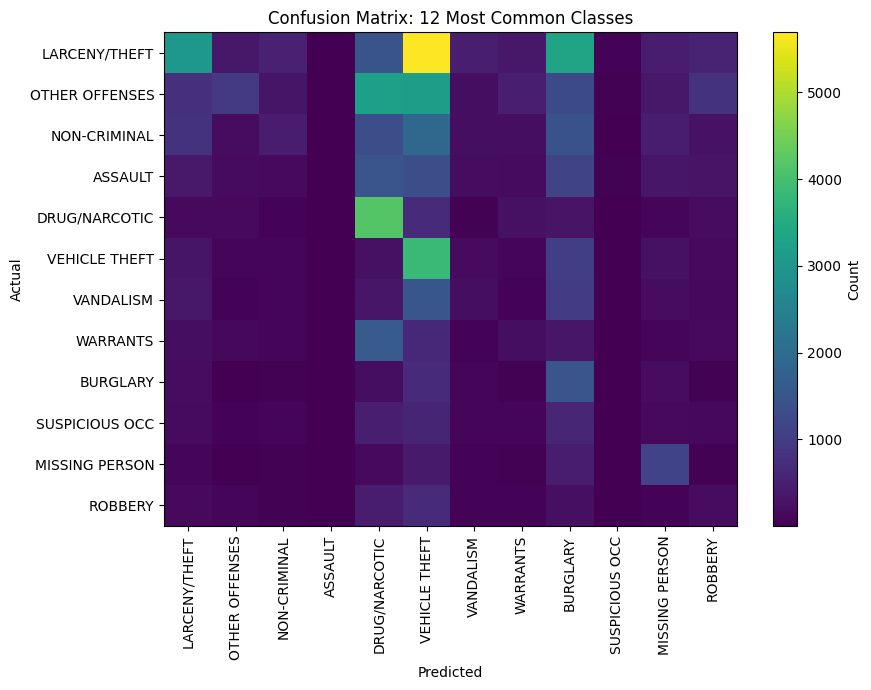

In [40]:
# Confusion matrix among the 12 most common actual classes
common_classes = list(y_valid.value_counts().head(12).index)
cm = confusion_matrix(y_valid, best_results['valid_pred'], labels=common_classes)
cm_df = pd.DataFrame(cm, index=common_classes, columns=common_classes)
plt.figure(figsize=(9,7))
plt.imshow(cm_df, aspect='auto')
plt.colorbar(label='Count')
plt.xticks(range(len(common_classes)), common_classes, rotation=90)
plt.yticks(range(len(common_classes)), common_classes)
plt.title('Confusion Matrix: 12 Most Common Classes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 11. Create Kaggle submissions
Kaggle requires one `Id` column followed by one probability column for each crime category. The notebook writes separate submissions for the decision tree, random forest, and calibrated SVM.

In [41]:
submission_dt = make_submission(dt_results['model'], 'submission_decision_tree.csv')
submission_rf = make_submission(rf_results['model'], 'submission_random_forest.csv')
submission_svm = make_submission(svm_results['model'], 'submission_svm.csv')

# Confirm row probabilities sum to one
for name, sub in [('DT', submission_dt), ('RF', submission_rf), ('SVM', submission_svm)]:
    row_sums = sub.drop(columns=['Id']).sum(axis=1)
    print(name, row_sums.min(), row_sums.max())


Wrote submission_decision_tree.csv: (884262, 40)
Wrote submission_random_forest.csv: (884262, 40)
Wrote submission_svm.csv: (884262, 40)
DT 0.9999999999999996 1.0000000000000004
RF 0.9999999999999993 1.0000000000000007
SVM 0.9999999999999993 1.0000000000000007
